In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import seaborn as sns
import matplotlib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pickle
import warnings
warnings.filterwarnings("ignore")

## Vanilla

In [5]:
# RnC
# CF + CT
# policytree
# Our method (IPW, DM, DR)
# KPT, BPT -- need to reconfigure this
# add dumb predictor (assign everything 1)
df = pd.DataFrame()
y = 'oos_optimal_treatment'
for m, m_method in zip(['IPW', 'DM', 'DR', 'Kallus', 'Bertsimas'], ['IPW', 'DM', 'DR', 'K-PT', 'B-PT']):
    df_buffer = pd.read_csv(f'../../results/synthetic/compiled/{m}.csv')
    df_buffer['method'] = m_method
    if m == 'DR':
        df_buffer = df_buffer[(df_buffer['budget'] == 1.0) & (df_buffer['propensity_score_pred'] == 'tree') &\
                             (df_buffer['ml'] == 'linear')]
    elif m == 'DM':
        df_buffer = df_buffer[(df_buffer['budget'] == 1.0) & \
                             (df_buffer['ml'] == 'linear')]
    elif m == 'IPW':
        df_buffer = df_buffer[(df_buffer['propensity_score_pred'] == 'tree')]
    
    df = pd.concat([df, df_buffer[['method', 'randomization', y]]], ignore_index=True)

# causal forest and trees
for m, m_name in zip(['cf', 'ct'], ['CF', 'CT']):
    df_buffer = pd.read_csv(f'../../results/synthetic/compiled/CF/{m}_raw.csv')
#     df_trans = pd.DataFrame(columns=['method', 'randomization', 'realized_outcome_oos'])
    cols=[f'p{i}' for i in [0.1, 0.25, 0.5, 0.75, 0.9]]
    for col in cols:
        h = pd.DataFrame({y: df_buffer[col].tolist()})
        h['method'] = m_name
        h['randomization'] = float(col[1:])
        df = pd.concat([df, h], ignore_index=False)
        
df_buffer = pd.read_csv(f'../../results/synthetic/compiled/RC/raw.csv')
df_buffer = df_buffer.rename(columns={'oosp': y, 'prob_opt': 'randomization'})
df_buffer = df_buffer[df_buffer['method'].isin(['lr'])][['method', 'randomization', y]]
df_buffer['method'] = 'RC (LR)'
df = pd.concat([df, df_buffer], ignore_index=False)

df = df.groupby(['method', 'randomization']).agg('mean').reset_index()
df['randomization'] = df['randomization'].astype(str)

In [6]:
# RnC
# CF + CT
# policytree
# Our method (IPW, DM, DR)
# KPT, BPT -- need to reconfigure this
# add dumb predictor (assign everything 1)
df1 = pd.DataFrame()
for m, m_method in zip(['DR', 'Kallus', 'Bertsimas'], ['DR', 'K-PT', 'B-PT']):
    df_buffer = pd.read_csv(f'../../results/synthetic/compiled/{m}.csv')
    df_buffer['method'] = m_method
    if m == 'DR':
        df_buffer = df_buffer[(df_buffer['budget'] == 1.0)]
        df_buffer = df_buffer[~((df_buffer['ml'] == 'lasso') & (df_buffer['propensity_score_pred'] == 'log'))]
        df_buffer['ml'] = df_buffer['ml'].map({'linear': 'LR', 'lasso': 'Lasso'})
        df_buffer['propensity_score_pred'] = df_buffer['propensity_score_pred'].map({'log': 'Log', 'tree': 'DT'})
        df_buffer['method'] = df_buffer.apply(lambda row: f"{row['method']} ({row['ml']}, {row['propensity_score_pred']})", axis=1)
    elif m == 'DM':
        df_buffer = df_buffer[(df_buffer['budget'] == 1.0) & \
                             (df_buffer['ml'] == 'linear')]
    elif m == 'IPW':
        df_buffer = df_buffer[(df_buffer['propensity_score_pred'] == 'tree')]
    
    df1 = pd.concat([df1, df_buffer[['method', 'randomization', y]]], ignore_index=True)
    
# policytree
df_buffer = pd.read_csv(f'../../results/synthetic/compiled/policytree/raw.csv')
cols=[f'p{i}' for i in [0.1, 0.25, 0.5, 0.75, 0.9]]
for col in cols:
    h = pd.DataFrame({y: df_buffer[col].tolist()})
    h['method'] = 'PT'
    h['randomization'] = float(col[1:])
    df1 = pd.concat([df1, h], ignore_index=False)
    
df1 = df1.groupby(['method', 'randomization']).agg('mean').reset_index()
df1['randomization'] = df1['randomization'].astype(str)
    
# causal forest and trees
# for m, m_name in zip(['cf', 'ct'], ['CF', 'CT']):
#     df_buffer = pd.read_csv(f'other_methods/results/CF/synthetic/{m}_raw.csv')
# #     df_trans = pd.DataFrame(columns=['method', 'randomization', 'realized_outcome_oos'])
#     for col in df_buffer.columns:
#         h = pd.DataFrame({y: df_buffer[col].tolist()})
#         h['method'] = m_name
#         h['randomization'] = float(col[1:])
#         df1 = pd.concat([df1, h], ignore_index=False)
        
# # policytree
# df_buffer = pd.read_csv(f'other_methods/results/policytree/synthetic/raw.csv')
# for col in df_buffer.columns:
#     h = pd.DataFrame({y: df_buffer[col].tolist()})
#     h['method'] = 'policytree'
#     h['randomization'] = float(col[1:])
#     df1 = pd.concat([df1, h], ignore_index=False)

# df_buffer = pd.read_csv(f'other_methods/results/RC/synthetic/raw.csv')
# df_buffer = df_buffer.rename(columns={'oosp': y, 'prob_opt': 'randomization'})
# df_buffer = df_buffer[df_buffer['method'].isin(['lr'])][['method', 'randomization', y]]
# df_buffer['method'] = 'RC (LR)'
# df1 = pd.concat([df1, df_buffer], ignore_index=False)

In [7]:
df[y] = df[y]*100
df1[y] = df1[y]*100

In [8]:
colors = ["#FFC7C7", "#FFA4A4", "#EB6262",
         "#BFBFBF", "#878787",
          "#CCDA2F",
         "#7B79CF"]

customPalette = sns.color_palette(colors)


colors1 = ["#EB6262", "#EB6262", "#EB6262",
         "#BFBFBF", "#878787"]

customPalette1 = sns.color_palette(colors1)

In [9]:
dash_list = sns._core.unique_dashes(3)[1:]

AttributeError: module 'seaborn._core' has no attribute 'unique_dashes'

In [10]:
dash_list = [(4, 1.5), (1, 1)]


In [22]:
dash_list

[(4, 1.5), (1, 1)]

In [11]:
colors = ["#FFC7C7", "#FFA4A4", "#EB6262",
         "#BFBFBF", "#878787",
         "#7B79CF"]

customPalette = sns.color_palette(colors)


colors1 = ["#EB6262", "#EB6262", "#EB6262", "#CCDA2F"]

customPalette1 = sns.color_palette(colors1)

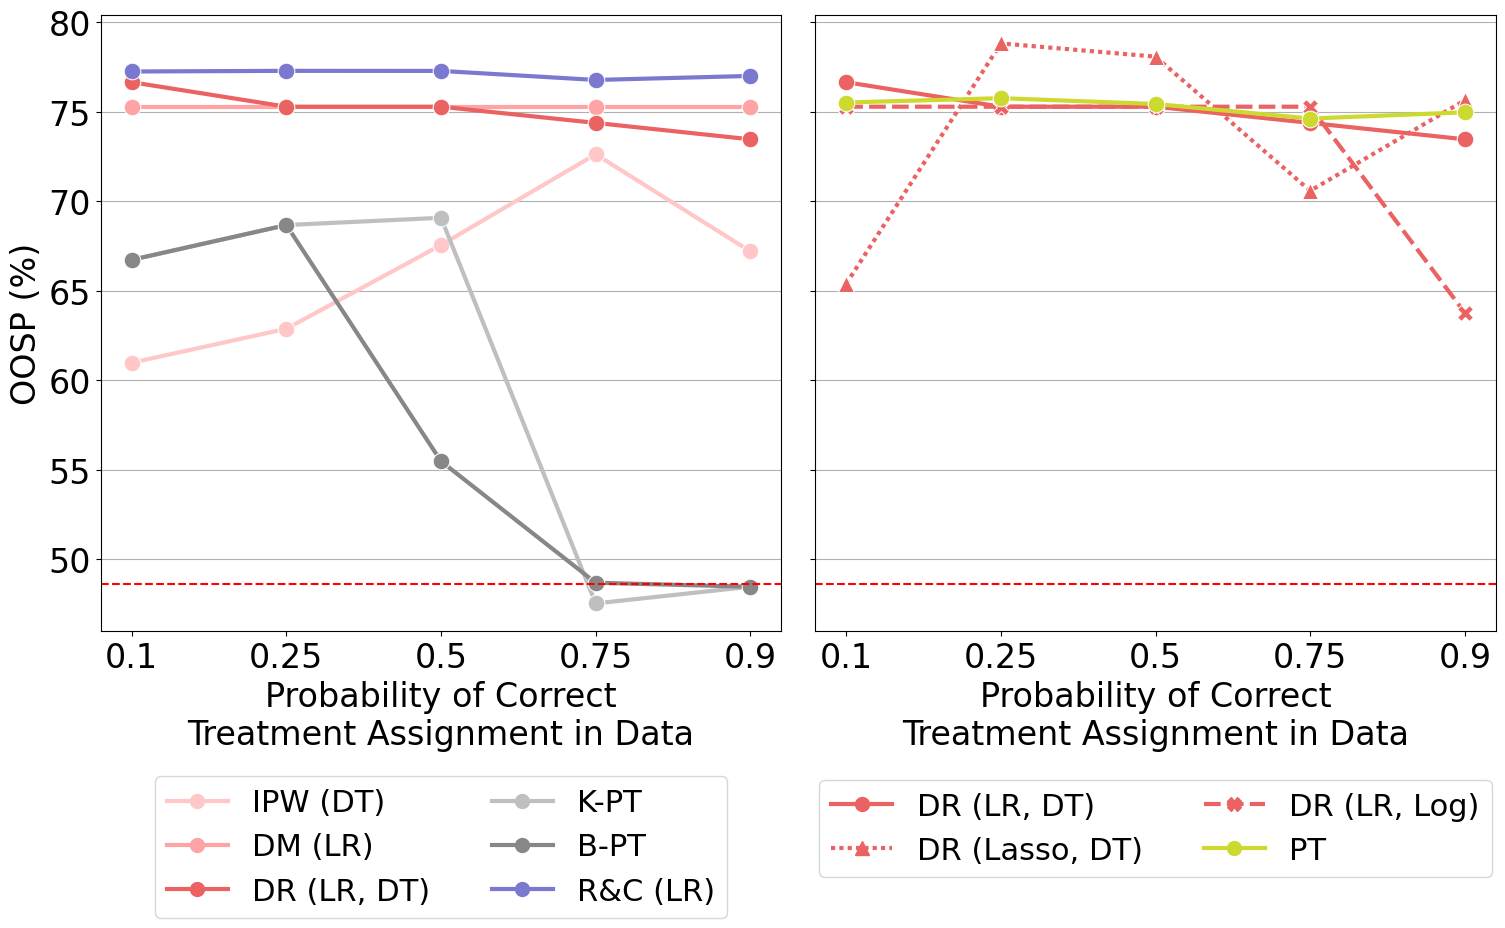

In [13]:
import copy
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
matplotlib.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 8), sharey=True)
for i in range(2):
    if i == 0:
        include = ['IPW', 'DM', 'DR', 'K-PT', 'B-PT', 'RC (LR)']
        sns.lineplot(data=df[df['method'].isin(include)], x='randomization', y=y, hue='method', 
                hue_order = include,
                marker='o', markersize=12, ax=ax[i], linewidth=3, palette=customPalette)
        ax[i].axhline(y = 0.486046*100, color = 'r', linestyle = '--')
        ax[i].set_ylabel('OOSP (%)')
        
        order_dummy=['IPW (DT)', 'DM (LR)', 'DR (LR, DT)', 'K-PT', 'B-PT', 'R&C (LR)']
        color_order_legend = {k: v for k, v in zip(order_dummy, colors)}
        legend_elements = [Line2D([0], [0], color=v, label=k, linewidth=3, marker='o', markersize=10) for k, v in color_order_legend.items()]
        
        ax[i].legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.35), ncol=2, fontsize=22)
    elif i == 1:
        include = ['DR (LR, DT)', 'DR (Lasso, DT)', 'DR (LR, Log)', 'PT']
        
        sns.lineplot(data=df1[df1['method'].isin(include)], x='randomization', y=y, hue='method', style='method',
            hue_order = include, markers=['o', 'X', '^', 'o'], markersize=12, ax=ax[i], linewidth=3, palette=customPalette1,
                    dashes=['', (4, 1.5), (1, 1), ''])
        ax[i].axhline(y = 0.486046*100, color = 'r', linestyle = '--')
        
        order_dummy=['DR (LR, DT)', 'DR (Lasso, DT)', 'DR (LR, Log)', 'PT', '1', '2']
        color_dummy=["#EB6262", "#EB6262", "#EB6262", "#CCDA2F", "#CCDA2F", "#CCDA2F"]
        marker_dummy=['o', '^', 'X', 'o', 'o', 'o']
        color_order_legend = {k: (v, v1) for k, v, v1 in zip(order_dummy, color_dummy, marker_dummy)}
        legend_elements = [Line2D([0], [0], color=v[0], label=k, linewidth=3, marker=v[1], markersize=10) for k, v in color_order_legend.items()]
        # ax[i].legend(handles=handles, labels=labels, loc='center', bbox_to_anchor=(0.5, -0.32), ncol=2, fontsize=22)
        
        handles, labels = ax[i].get_legend_handles_labels()
        # copy the handles
        handles = [copy.copy(ha) for ha in handles]
        # set the linewidths to the copies
        [ha.set_linewidth(3) for ha in handles ]
        [ha.set_markersize(10) for ha in handles ]
        ax[i].legend(handles=handles, labels=labels, loc='center', bbox_to_anchor=(0.5, -0.32), ncol=2, fontsize=22)

    ax[i].set_xlabel('Probability of Correct\nTreatment Assignment in Data')
    ax[i].grid(visible=True, axis='y')
    
plt.subplots_adjust(wspace=0.05)
# plt.savefig('figs/synthetic_main.pdf', bbox_inches='tight')
plt.show()

## Budget Constraints

In [14]:
def split_d1(row, branching, leaves):
    if row[branching[0]] == 0:
        return row[f'y{leaves[0]}']
    else:
        return row[f'y{leaves[1]}']
    
def split_d1_prob(row, branching, leaves):
    if row[branching[0]] == 0:
        return row[f'y{np.random.choice(np.arange(2), p=list(leaves[0].values()))}']
    else:
        return row[f'y{np.random.choice(np.arange(2), p=list(leaves[1].values()))}']
    
def split_d2(row, branching, leaves):
    if row[branching[0]] == 0:
        if row[branching[1]] == 0:
            return row[f'y{leaves[0]}']
        else:
            return row[f'y{leaves[1]}']
    else:
        if row[branching[2]] == 0:
            return row[f'y{leaves[2]}']
        else:
            return row[f'y{leaves[3]}']

def split_d2_prob_coinflip(row, branching, leaves):
    if row[branching[0]] == 0:
        if row[branching[1]] == 0:
            return row[f'y{np.random.choice(np.arange(3), p=list(leaves[0].values()))}']
        else:
            return row[f'y{np.random.choice(np.arange(3), p=list(leaves[1].values()))}']
    else:
        if row[branching[2]] == 0:
            return row[f'y{np.random.choice(np.arange(3), p=list(leaves[2].values()))}']
        else:
            return row[f'y{np.random.choice(np.arange(3), p=list(leaves[3].values()))}']
        
def split_d2_prob(row, branching, leaves):
    if row[branching[0]] == 0:
        if type(branching[1]) == dict:
            return np.sum(branching[1][k] * row[f'y{k}'] for k in range(3))
        else:
            if row[branching[1]] == 0:
                return np.sum(leaves[0][k] * row[f'y{k}'] for k in range(3))
            else:
                return np.sum(leaves[1][k] * row[f'y{k}'] for k in range(3))
    else:
        if type(branching[2]) == dict:
            return np.sum(branching[2][k] * row[f'y{k}'] for k in range(3))
        else:
            if row[branching[2]] == 0:
                return np.sum(leaves[2][k] * row[f'y{k}'] for k in range(3))
            else:
                return np.sum(leaves[3][k] * row[f'y{k}'] for k in range(3))
        
def split_d3(row, branching, leaves):
    if row[branching[0]] == 0:
        if 'pruned' not in branching[1]:
            if row[branching[1]] == 0:
                if 'pruned' not in branching[3]:
                    if row[branching[3]] == 0:
                        return row[f'y{leaves[0]}']
                    else:
                        return row[f'y{leaves[1]}']
                else:
                    return row[f'y{branching[3][-1]}']
            else:
                if 'pruned' not in branching[4]:
                    if row[branching[4]] == 0:
                        return row[f'y{leaves[2]}']
                    else:
                        return row[f'y{leaves[3]}']
                else:
                    return row[f'y{branching[4][-1]}']
        else:
            return row[f'y{branching[1][-1]}']
    else:
        if 'pruned' not in branching[2]:
            if row[branching[2]] == 0:
                if 'pruned' not in branching[5]:
                    if row[branching[5]] == 0:
                        return row[f'y{leaves[4]}']
                    else:
                        return row[f'y{leaves[5]}']
                else:
                    return row[f'y{branching[5][-1]}']
            else:
                if 'pruned' not in branching[6]:
                    if row[branching[6]] == 0:
                        return row[f'y{leaves[6]}']
                    else:
                        return row[f'y{leaves[7]}']
                else:
                    return row[f'y{branching[6][-1]}']
        else:
            return row[f'y{branching[2][-1]}']
            
def assign_d1(row, branching, leaves):
    if row[branching[0]] == 0:
        return int(leaves[0])
    else:
        return int(leaves[1])
    
def assign_d1_prob(row, branching, leaves):
    if row[branching[0]] == 0:
        return np.random.choice(np.arange(2), p=list(leaves[0].values()))
    else:
        return np.random.choice(np.arange(2), p=list(leaves[1].values()))
    
def assign_d2(row, branching, leaves):
    if row[branching[0]] == 0:
        if row[branching[1]] == 0:
            return int(leaves[0])
        else:
            return int(leaves[1])
    else:
        if row[branching[2]] == 0:
            return int(leaves[2])
        else:
            return int(leaves[3])
        
def assign_d2_prob_coinflip(row, branching, leaves):
    if row[branching[0]] == 0:
        if row[branching[1]] == 0:
            return np.random.choice(np.arange(3), p=list(leaves[0].values()))
        else:
            return np.random.choice(np.arange(3), p=list(leaves[1].values()))
    else:
        if row[branching[2]] == 0:
            return np.random.choice(np.arange(3), p=list(leaves[2].values()))
        else:
            return np.random.choice(np.arange(3), p=list(leaves[3].values()))
        
def assign_d2_prob(row, branching, leaves):
    if row[branching[0]] == 0:
        if type(branching[1]) == dict:
            return branching[1]
        else:
            if row[branching[1]] == 0:
                return leaves[0]
            else:
                return leaves[1]
    else:
        if type(branching[2]) == dict:
            return branching[2]
        else:
            if row[branching[2]] == 0:
                return leaves[2]
            else:
                return leaves[3]
        
def assign_d3(row, branching, leaves):
    if row[branching[0]] == 0:
        if 'pruned' not in branching[1]:
            if row[branching[1]] == 0:
                if 'pruned' not in branching[3]:
                    if row[branching[3]] == 0:
                        return int(leaves[0])
                    else:
                        return int(leaves[1])
                else:
                    return int(branching[3][-1])
            else:
                if 'pruned' not in branching[4]:
                    if row[branching[4]] == 0:
                        return int(leaves[2])
                    else:
                        return int(leaves[3])
                else:
                    return int(branching[4][-1])
        else:
            return int(branching[1][-1])
    else:
        if 'pruned' not in branching[2]:
            if row[branching[2]] == 0:
                if 'pruned' not in branching[5]:
                    if row[branching[5]] == 0:
                        return int(leaves[4])
                    else:
                        return int(leaves[5])
                else:
                    return int(branching[5][-1])
            else:
                if 'pruned' not in branching[6]:
                    if row[branching[6]] == 0:
                        return int(leaves[6])
                    else:
                        return int(leaves[7])
                else:
                    return int(branching[6][-1])
        else:
            return int(branching[2][-1])

In [19]:
randomization = [0.1, 0.25, 0.5, 0.75, 0.9]
splits = [1, 2, 3, 4, 5]
budgets = [0.1, 0.2, 1.0]

results_synthetic = pd.DataFrame(columns=['split', 'randomization', 'budget', 'tree_depth', 'propensity_score_pred',
                                          'ml', 'oos_regret', 'oos_optimal_treatment', 'oos_avg_outcome', 'tree'])
for r in randomization:
    for split in splits:
        fp_data = f'../../data/processed/synthetic/'
        df_train = pd.read_csv(os.path.join(fp_data, f'data_train_enc_{r}_{split}.csv'))
        df_test = pd.read_csv(os.path.join(fp_data, f'data_test_enc_{r}_{split}.csv'))

        df_train_raw = pd.read_csv(os.path.join(fp_data, f'data_train_{r}_{split}.csv'))
        df_test_raw = pd.read_csv(os.path.join(fp_data, f'data_test_{r}_{split}.csv'))
        
        # calculate optional treatment and outcome
        df_test['opt_t'] = df_test.apply(lambda row: 0 if row['y0'] > row['y1'] else 1, axis=1)
        df_test['opt_y'] = df_test.apply(lambda row: row['y0'] if row['y0'] > row['y1'] else row['y1'], axis=1)
        
        # loop through types of ML and preds
        for budget in budgets:
            results_fp = f'../../results/synthetic/raw/DR/budget/'
            for pred in ['tree', 'log']:
                for ml in ['linear', 'lasso']:
                    tree = {}
                    for d in [1]:
                        fn = f'data_train_enc_{r}_{split}_Robust_d_{d}_t_3600_branching_limit_100.0_pred_{pred}_ml_{ml}_budget_{budget}.p'
#                         # THIS IS TEMPORARY BECAUSE .p didn't exist
#                         if os.path.exists(os.path.join(results_fp, fn)):
                        
                        with open(os.path.join(results_fp, fn), 'rb') as f:
                            tree[d] = pickle.load(f)

                        df_test['y_d1'] = df_test.apply(lambda row: split_d1_prob(row, tree[1]['branching'], 
                                                                            tree[1]['leaves']), axis=1)
                        df_test['t_d1'] = df_test.apply(lambda row: assign_d1_prob(row, tree[1]['branching'], 
                                                                            tree[1]['leaves']), axis=1)

    #                     df_test['y_d2'] = df_test.apply(lambda row: split_d1_prob(row, tree[2]['branching'], 
    #                                                                         tree[2]['leaves']), axis=1)
    #                     df_test['t_d2'] = df_test.apply(lambda row: assign_d1_prob(row, tree[2]['branching'], 
    #                                                                         tree[2]['leaves']), axis=1)

                    for d in [1]:
                        df_test['regret'] = df_test['opt_y']-df_test[f'y_d{d}']
                        optimal_treatment_perc = (df_test['t_d1'] == df_test['opt_t']).sum()/len(df_test)
                        avg_outcome = df_test[f'y_d{d}'].mean()

                        results_synthetic.loc[len(results_synthetic)] = [split, r, budget, d, pred, ml, df_test['regret'].sum(),
                                                                        optimal_treatment_perc, avg_outcome, tree[d]]

FileNotFoundError: [Errno 2] No such file or directory: '../../results/synthetic/raw/DR/budget/data_train_enc_0.1_1_Robust_d_1_t_3600_branching_limit_100.0_pred_tree_ml_linear_budget_0.1.p'

In [21]:
results_synthetic = pd.read_csv('../../results/synthetic/compiled/DR_new.csv')

In [22]:
results_synthetic['budget'] *= 100
results_synthetic['oos_optimal_treatment'] *= 100

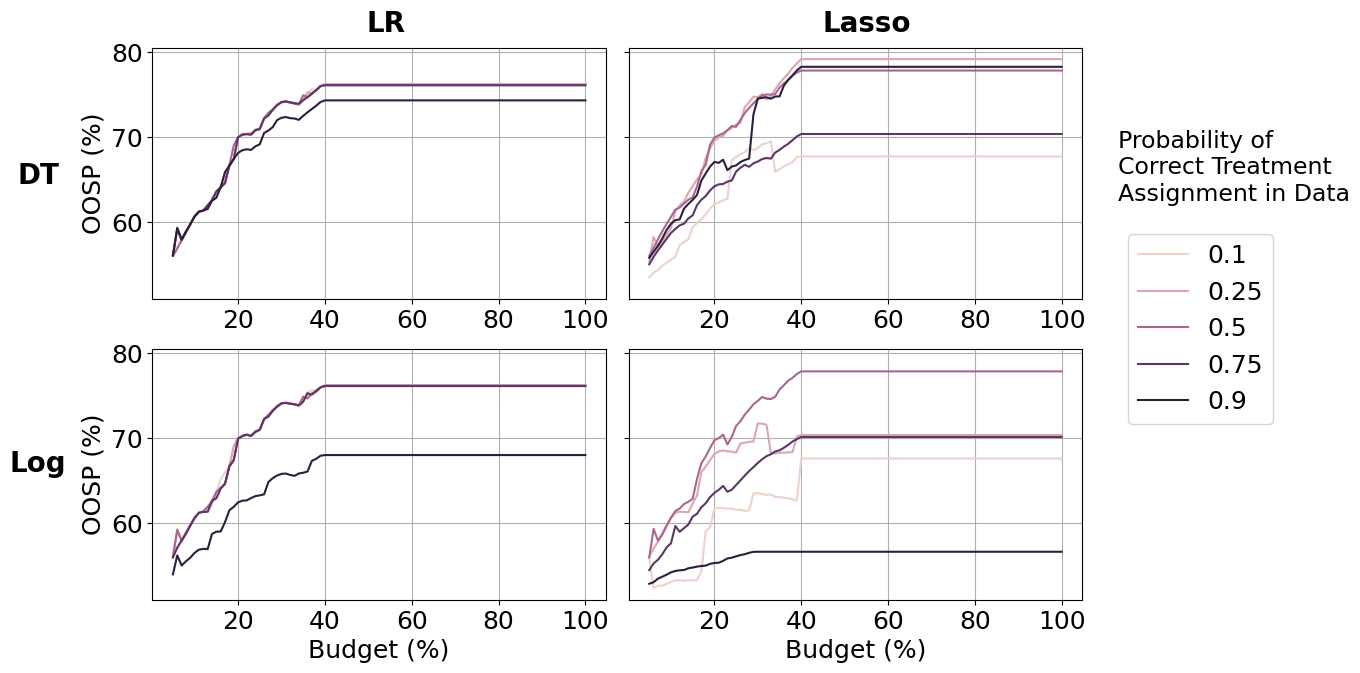

In [23]:
matplotlib.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for pred, ml, x, y in zip(['tree', 'tree', 'log', 'log'], ['linear', 'lasso', 'linear', 'lasso'], [0, 0, 1, 1], [0, 1, 0, 1]):
    sub = results_synthetic[(results_synthetic['propensity_score_pred'] == pred) & \
                                (results_synthetic['ml'] == ml)][['budget', 'randomization', 
                                            'oos_optimal_treatment']].groupby(['budget', 'randomization']).agg('mean').reset_index()
    sns.lineplot(data=sub, 
         y='oos_optimal_treatment', x='budget', hue='randomization', ax=ax[x, y])
    
    if x != 0 or y != 1:
        leg = ax[x, y].get_legend()
        leg.remove()
    else:
        ax[x, y].legend(loc=(1.1, -0.5))
    
    if x == 0:
        ax[x, y].set_xlabel('')
    else:
#         ax[x, y].set_xlabel('Probability of Correct\nTreatment Assignment in Data')
        ax[x, y].set_xlabel('Budget (%)')
        
    if y == 0:
        ax[x, y].set_ylabel('OOSP (%)')
    ax[x, y].grid(True)
#     ax[x, y].set_xticks([0.1, 0.25, 0.5, 0.75, 0.9])
fig.text(0.32, 0.83, 'LR', ha='center', va='center', weight='bold', size='20')
fig.text(0.72, 0.83, 'Lasso', ha='center', va='center', weight='bold', size='20')
fig.text(0.03, 0.64, 'DT', ha='center', va='center', weight='bold', size='20')
fig.text(0.03, 0.28, 'Log', ha='center', va='center', weight='bold', size='20')
fig.text(0.93, 0.65, 'Probability of\nCorrect Treatment\nAssignment in Data', ha='left', va='center', size='17')
plt.subplots_adjust(top=0.8, wspace=0.05)
# plt.savefig('figs/budget_synthetic.pdf', bbox_inches='tight')
plt.show()

In [148]:
results_synthetic_4 = results_synthetic[results_synthetic['budget'] == 0.4]
results_synthetic_1 = results_synthetic[results_synthetic['budget'] == 1]

In [151]:
results_synthetic_1_copy = results_synthetic_4.copy()
results_synthetic_1_copy['budget'] = 1.0

In [152]:
results_synthetic = pd.concat([results_synthetic[results_synthetic['budget'] != 1], results_synthetic_1_copy],
                             ignore_index=True)

In [155]:
results_synthetic.to_csv('Results_Atheyv1/compiled_results/DR_new.csv', index=False)